# Project 03 — Toxic vs Non-Toxic Text Classification

# Part A. Setup

### Members' Full Name and Student ID
- **Ricardo Ruiz** — 300387021  
- **Hugh Tran** — 300394597  
- **Jimmy Suwarly** — 300361475  
- **Nguyen Mai Dinh Le (Demi)** — 300312139

### References
- CSIS 3400 lecture notes and lab materials
- Project 03 instructions (`Proj03.pdf`)
- NLTK documentation
- VaderSentiment documentation
- spaCy documentation
- gensim Word2Vec documentation
- scikit-learn documentation

## Imported Libraries

This notebook keeps most imports in one place to match the structure used in previous projects.  
If a package is missing in your environment, install it before the final run.

In [27]:
%pip install vaderSentiment gensim spacy nltk scikit-learn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [28]:
%pip install spacy
!python -m spacy download en_core_web_lg

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 27.9 MB/s  0:00:14:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')


In [ ]:
# Core libraries
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data split and models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# NLP tools
import nltk
from O5_smtd_preprocessing import process_TweetText
from nltk.tokenize import TweetTokenizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim.models import Word2Vec

warnings.filterwarnings("ignore")

# Download NLTK resources if needed
nltk.download("punkt", quiet=True)

RANDOM_STATE = 42
TEST_SIZE = 0.1

## 1. Load Dataset and Prepare Labels

The project file states that the dataset contains two fields: **text** and **is_toxic**, and that the data must be split using **test_size = 0.1** and **random_state = 42**.

In [29]:
# Load the project dataset
df = pd.read_csv("toxicity_en.csv")

# Preview the dataset
print("Dataset shape:", df.shape)
display(df.head())

# Standardize labels to numeric values for modeling
label_map = {
    "Toxic": 1,
    "Not Toxic": 0,
    1: 1,
    0: 0
}
df["label"] = df["is_toxic"].map(label_map)

print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df[["text", "is_toxic", "label"]].isnull().sum())
print("\nClass distribution:\n", df["is_toxic"].value_counts())

Dataset shape: (1000, 2)


,text,is_toxic
0,"Elon Musk is a piece of shit, greedy capitalis...",Toxic
1,The senile credit card shrill from Delaware ne...,Toxic
2,He does that a lot -- makes everyone look good...,Toxic
3,F*ck Lizzo,Toxic
4,Epstein and trump were best buds!!! Pedophiles...,Toxic



Columns: ['text', 'is_toxic', 'label']

Missing values:
 text        0
is_toxic    0
label       0
dtype: int64

Class distribution:
 is_toxic
Toxic        501
Not Toxic    499
Name: count, dtype: int64


## 2. Train-Test Split

We keep a copy of the raw text for all three modeling parts.  
The split is done once here so the whole group works with the same training and test sets.

In [30]:
# Drop rows with missing required values, if any
df = df.dropna(subset=["text", "label"]).copy()

# Split the dataset once for the entire notebook
train_df, test_df = train_test_split(
    df[["text", "is_toxic", "label"]],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTraining label distribution:")
print(train_df["is_toxic"].value_counts(normalize=True))

print("\nTest label distribution:")
print(test_df["is_toxic"].value_counts(normalize=True))

Training shape: (900, 3)
Test shape: (100, 3)

Training label distribution:
is_toxic
Toxic        0.501111
Not Toxic    0.498889
Name: proportion, dtype: float64

Test label distribution:
is_toxic
Toxic        0.5
Not Toxic    0.5
Name: proportion, dtype: float64


## 3. Shared Evaluation Helper

This helper is reused in Parts B, C, and D so the notebook stays consistent.

In [31]:
def evaluate_predictions(y_true, y_pred, model_name):
    """Print standard evaluation outputs required by the project."""
    acc = accuracy_score(y_true, y_pred)
    print(f"{model_name} Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Toxic", "Toxic"])
    disp.plot(cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    return acc, cm

# Part B. Unsupervised Model: VaderSentiment

**Ricardo Ruiz**  

### Goal
Use **VaderSentiment** as a pre-trained sentiment model and search for the **best compound-score threshold** on the training set.  
Then use that threshold to predict toxicity on the test set.

### What this part must prove
This section must show that the threshold was **searched systematically on the training set**, not selected by guesswork.  
After that, the chosen threshold is applied once on the test set to report the official Part B performance.


### 1. Vader Compound Score Exploration

VADER returns four scores: `neg`, `neu`, `pos`, and `compound`.  
For this project, we test threshold values on the **compound** score and label a post as **Toxic** when the score is at or below the selected threshold.

In [32]:
# Initialize the VADER analyzer
vader = SentimentIntensityAnalyzer()

# Compute compound scores for the training and test sets
train_df["vader_compound"] = train_df["text"].astype(str).apply(
    lambda x: vader.polarity_scores(x)["compound"]
)
test_df["vader_compound"] = test_df["text"].astype(str).apply(
    lambda x: vader.polarity_scores(x)["compound"]
)

display(train_df[["text", "is_toxic", "vader_compound"]].head())

,text,is_toxic,vader_compound
0,That was also my favourite part to edit / what...,Not Toxic,0.8377
1,"Imagine being such a pos, when you die, litera...",Toxic,0.4738
2,What’s “the big lie”? I keep hearing CNN lizar...,Toxic,-0.6381
3,"Finally a real first lady, not a transvestite ...",Toxic,-0.4939
4,I was like wtf is attack speed ratio and took ...,Not Toxic,-0.2263


### 2. Search for the Best Threshold on the Training Set

We evaluate many candidate thresholds and choose the one that gives the highest **training accuracy**.

In [33]:
# Search a grid of candidate thresholds
thresholds = np.arange(-1.00, 1.01, 0.01)
threshold_results = []

for threshold in thresholds:
    pred_train = (train_df["vader_compound"] <= threshold).astype(int)
    acc = accuracy_score(train_df["label"], pred_train)
    threshold_results.append((threshold, acc))

threshold_df = pd.DataFrame(threshold_results, columns=["threshold", "train_accuracy"])
threshold_df = threshold_df.sort_values(["train_accuracy", "threshold"], ascending=[False, True]).reset_index(drop=True)

best_threshold = threshold_df.loc[0, "threshold"]
best_train_accuracy = threshold_df.loc[0, "train_accuracy"]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best training accuracy: {best_train_accuracy:.4f}")
display(threshold_df.head(10))

Best threshold: -0.05
Best training accuracy: 0.7344


,threshold,train_accuracy
0,-0.05,0.734444
1,-0.02,0.734444
2,-0.07,0.733333
3,-0.04,0.733333
4,-0.03,0.733333
5,-0.01,0.733333
6,-0.12,0.732222
7,-0.11,0.732222
8,-0.09,0.732222
9,-0.08,0.732222


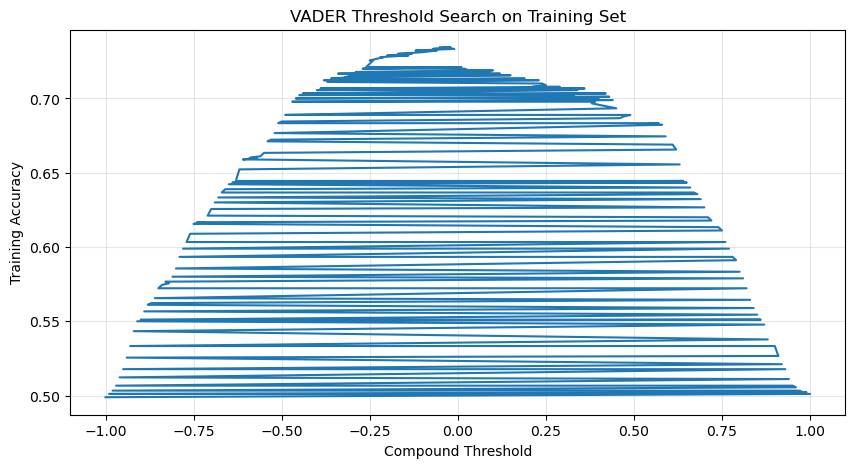

In [34]:
# Optional visualization of threshold search
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["train_accuracy"])
plt.xlabel("Compound Threshold")
plt.ylabel("Training Accuracy")
plt.title("VADER Threshold Search on Training Set")
plt.grid(True, alpha=0.3)
plt.show()

### 3. Evaluation on the Test Set

Use the best threshold found in the training set and evaluate it on the test set with:
- Accuracy
- Confusion matrix
- Classification report

Part B - VaderSentiment Accuracy: 0.6600

Classification Report:
              precision    recall  f1-score   support

           0     0.6212    0.8200    0.7069        50
           1     0.7353    0.5000    0.5952        50

    accuracy                         0.6600       100
   macro avg     0.6783    0.6600    0.6511       100
weighted avg     0.6783    0.6600    0.6511       100



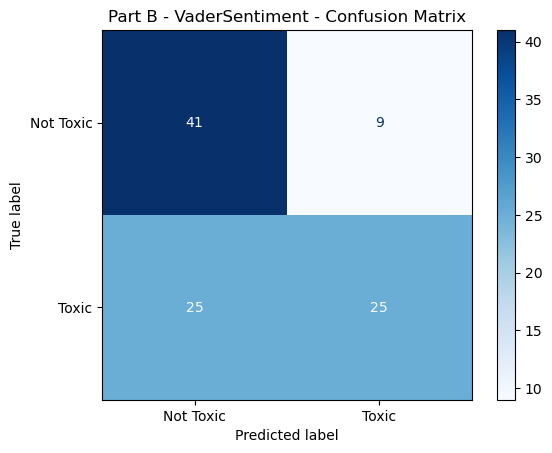

In [35]:
# Apply the selected threshold to the test set
test_df["pred_vader"] = (test_df["vader_compound"] <= best_threshold).astype(int)

acc_b, cm_b = evaluate_predictions(
    y_true=test_df["label"],
    y_pred=test_df["pred_vader"],
    model_name="Part B - VaderSentiment"
)

### 4. Part B Short Analysis

In Part B, we used **VaderSentiment** as an unsupervised baseline model. Since VADER is already pre-trained, the main task was to search for the **best compound score threshold** on the **training set** and then apply that threshold to the **test set** for toxicity prediction.

The threshold search showed that the **best threshold was -0.05**, with a **best training accuracy of 0.7344**. This threshold is very close to **neutral sentiment**, but slightly on the negative side. That result suggests that posts do not need to be strongly negative to be classified as toxic. Instead, the best separation between toxic and non-toxic posts in the training set happens when even **slightly negative sentiment** is treated as a signal of toxicity.

Another important observation is that the best-performing thresholds are all concentrated near zero, such as **-0.12, -0.11, -0.09, -0.08, -0.07, -0.05, -0.04, -0.03, -0.02, and -0.01**. This pattern shows that the model performs best around the **neutral-to-negative boundary**. If the threshold is too negative, the model misses many toxic posts. If the threshold is too positive, it starts predicting too many posts as toxic. Therefore, **-0.05** gives the best balance on the training data.

Using this selected threshold, the model achieved a **test accuracy of 0.6600**. This means VADER correctly classified **66 out of 100 posts** in the test set. Based on the confusion matrix, the model correctly identified **41 non-toxic posts** and **25 toxic posts**, while it misclassified **9 non-toxic posts as toxic** and **25 toxic posts as non-toxic**.

The classification report shows that for the **non-toxic class (0)**, the model obtained a **precision of 0.6212**, a **recall of 0.8200**, and an **F1-score of 0.7069**. For the **toxic class (1)**, it achieved a **precision of 0.7353**, a **recall of 0.5000**, and an **F1-score of 0.5952**. These results indicate that the model is better at detecting **non-toxic posts** than **toxic posts**, because it only found half of the actual toxic examples.

Overall, these results suggest that **sentiment alone is only moderately effective for toxicity classification**. VADER can capture clearly negative language, but toxicity depends on more than sentiment. Some toxic posts may contain sarcasm, insults, or offensive intent without appearing strongly negative, which leads to **false negatives**. At the same time, some non-toxic posts may include complaints, frustration, or emotionally negative language, which may produce **false positives**.

In conclusion, Part B provides a useful baseline and shows that sentiment has some predictive value. However, the gap between the **training accuracy (0.7344)** and the **test accuracy (0.6600)**, together with the confusion matrix and classification report, indicates that a sentiment-based approach is not sufficient on its own for fully reliable toxicity classification.

### How Part B satisfies the project requirement

This part satisfies the project requirement by:
1. using **VaderSentiment**,
2. searching for the **best compound score threshold** on the **training set**,
3. applying that threshold to the **test set**,
4. and reporting the **accuracy, confusion matrix, and classification report**.


# Part C. Supervised Model with Pre-trained Embedding

**Hugh Tran**  


### Goal
Use **spaCy `en_core_web_lg`** to convert each post into a dense vector embedding, then train a **Logistic Regression** classifier on the training set.

### What this part must prove
This section must show that:
1. each post is represented by a pre-trained embedding,
2. the classifier is trained on the training split only,
3. and the model is evaluated on the test set with the required metrics.


### 4. Evaluation on the Test Set

In [ ]:
# Predict on test data
pred_spacy = lr_spacy.predict(X_test_spacy)

acc_c, cm_c = evaluate_predictions(
    y_true=y_test,
    y_pred=pred_spacy,
    model_name="Part C - spaCy Embedding + Logistic Regression"
)

### 5. Part C Short Analysis

Use this section to explain **what the Part C results mean**.

**Write your final interpretation here after running the cells.**

Suggested structure:
- **Test accuracy:** `[fill value]`
- Explain whether Part C improved over Part B, and by approximately how much.
- Discuss why **dense pre-trained embeddings** may capture meaning better than a simple sentiment score.
- Mention any limitations of `en_core_web_lg` on short, informal, or slang-heavy social media posts.
- Comment on the confusion matrix: did the model reduce false positives, false negatives, or both?

### How Part C satisfies the project requirement
This part achieves the requirement by:
1. converting each post into a vector using **`en_core_web_lg`**,
2. training **Logistic Regression** on the training embeddings,
3. predicting on the test embeddings,
4. and reporting the **accuracy, confusion matrix, and classification report**.


# Part D. Supervised Model with Word2Vec

## Part D.1 Preprocessing

**Jimmy Suwarly**  


### Goal
Pre-process the `text` field using:
- **NLTK TweetTokenizer**
- the lecture helper **`O5_smtd_preprocessing.preprocessing`**

The result must be stored in a new field called **`tweet`**.

### Why this part is separated from D.2
Part D.2 depends on the output of D.1.  
For that reason, preprocessing is completed first and validated before the Word2Vec training starts.


### D.1 Important note

Because the assignment explicitly asks for the lecture preprocessing function, make sure the file  
**`O5_smtd_preprocessing.py`** is in the same folder as the notebook, or update the import path below.

This template includes a safe structure, but the group must confirm the exact function signature used in class.

### D.1 Quick Validation

Before moving to Word2Vec training, confirm:
- `tweet` exists in both train and test sets
- each row contains a token list
- preprocessing does not create too many empty posts

In [36]:


# Initialize TweetTokenizer
tweet_tokenizer = TweetTokenizer()

def preprocess_text(text):
    """
    Apply lecture preprocessing, then tokenize with TweetTokenizer.
    Returns a list of tokens.
    """
    text = str(text)
    # Apply the lecture preprocessing function
    processed = process_TweetText(text)
    # Tokenize using NLTK TweetTokenizer
    tokens = tweet_tokenizer.tokenize(processed)
    return tokens

# Apply preprocessing to both train and test sets
train_df["tweet"] = train_df["text"].apply(preprocess_text)
test_df["tweet"]  = test_df["text"].apply(preprocess_text)

print("Preprocessing complete.")
print("\nSample preprocessed tweets (train):")
for idx in range(3):
    print(f"  [{idx}] {train_df['tweet'].iloc[idx][:15]}...")

print(f"\nTrain tweets with tokens: {(train_df['tweet'].apply(len) > 0).sum()} / {len(train_df)}")
print(f"Test tweets with tokens:  {(test_df['tweet'].apply(len) > 0).sum()} / {len(test_df)}")

Preprocessing complete.

Sample preprocessed tweets (train):
  [0] ['that', 'was', 'also', 'my', 'favourite', 'part', 'to', 'edit', '/', 'what', 'originally', 'inspired', 'me', 'to', 'make']...
  [1] ['imagine', 'being', 'such', 'a', 'pos', ',', 'when', 'you', 'die', ',', 'literally', 'near', 'the', 'whole', 'world']...
  [2] ['whats', 'the', 'big', 'lie', '?', 'i', 'keep', 'hearing', 'cnn', 'lizard', 'people', 'talking', 'about', 'it', 'but']...

Train tweets with tokens: 900 / 900
Test tweets with tokens:  100 / 100


## Part D.2 Training + Part D.3 Evaluation

**Nguyen Mai Dinh Le (Demi)**  

### Goal
Train a **gensim Word2Vec** model on the training `tweet` field, represent each post by **summing word embeddings**, then train and evaluate **Logistic Regression**.

### What this part must prove
This section must clearly show:
1. the Word2Vec model is trained on the training tweets,
2. each post embedding is created by summing token vectors,
3. Logistic Regression is trained on those post embeddings,
4. and the final evaluation is reported on the test set.


### 4. Evaluation on the Test Set

In [ ]:
# Predict on the test data
pred_w2v = lr_w2v.predict(X_test_w2v)

acc_d, cm_d = evaluate_predictions(
    y_true=y_test,
    y_pred=pred_w2v,
    model_name="Part D - Word2Vec + Logistic Regression"
)

### 5. Part D Short Analysis

Use this section to explain **what the Part D results mean**.

**Write your final interpretation here after running the cells.**

Suggested structure:
- **Test accuracy:** `[fill value]`
- Compare Part D with Parts B and C.
- Explain whether a **custom Word2Vec representation** seems to fit this dataset well.
- Comment on the effect of representing each post by the **sum of token embeddings**.
- Mention one strength and one limitation of this approach on short social-media text.

### How Part D satisfies the project requirement
This part achieves the requirement by:
1. preprocessing the text into the required **`tweet`** field,
2. training **Word2Vec** on the training tweets,
3. creating each **post embedding** by summing token vectors,
4. training **Logistic Regression** on those embeddings,
5. and reporting the **accuracy, confusion matrix, and classification report** on the test set.


# Part E. Discussion and Conclusions

**Jimmy Suwarly**  

### Goal
Summarize the main observations from Parts B, C, and D and identify the strongest model for this dataset.

### What the discussion should do
The discussion should not only repeat the numbers.  
It should explain:
- which model worked best,
- why that result is reasonable,
- what limitations remain,
- and what the group learned from comparing the three approaches.


### 1. Model Comparison Table

In [ ]:
# Build a simple comparison table after all three models have been evaluated
comparison_df = pd.DataFrame({
    "Model": [
        "Part B - VaderSentiment",
        "Part C - spaCy Embedding + Logistic Regression",
        "Part D - Word2Vec + Logistic Regression"
    ],
    "Accuracy": [acc_b, acc_c, acc_d]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

display(comparison_df)

### 2. Discussion Prompts

Use the questions below to write a strong final discussion.

1. **Which model achieved the best test accuracy?**
2. **Was the improvement large or small?**  
   Explain whether the gain is meaningful or only marginal.
3. **What does Part B tell us about the limits of rule-based sentiment for toxicity detection?**
4. **Why might Part C perform well?**  
   Consider semantic information, pre-trained knowledge, and sentence-level representation.
5. **Why might Part D perform differently from Part C?**  
   Consider that Word2Vec is trained only on this dataset and that post vectors are built by summing word vectors.
6. **Which model would you recommend for this project and why?**
7. **What would the group improve next?**  
   Examples: better preprocessing, class balancing, hyperparameter tuning, or a more advanced model.

### Writing tip
Do not only restate the printed metrics.  
Interpret them and connect them back to the project goal: **accurately classifying toxic and non-toxic social media posts**.


### 3. Final Conclusion

Write one clear closing paragraph or a short set of bullet points.

Suggested structure:
- State the **best-performing model** clearly.
- Compare it briefly against the other two approaches.
- Explain whether the result matches your expectation.
- Mention one **main strength** of the project.
- Mention one **main limitation** of the project.
- End with a final sentence explaining what the group learned about **toxicity detection with NLP methods**.

**Fill after final run:**
- Best model: `[fill model name]`
- Best accuracy: `[fill value]`
- Main takeaway: `[fill short conclusion]`


## Member Contribution

Fill this table together before submission.

| Evaluator \ Evaluatee | Ricardo Ruiz | Hugh Tran | Jimmy Suwarly | Nguyen Mai Dinh Le (Demi) |
|---|---:|---:|---:|---:|
| **Ricardo Ruiz** |  |  |  |  |
| **Hugh Tran** |  |  |  |  |
| **Jimmy Suwarly** |  |  |  |  |
| **Nguyen Mai Dinh Le (Demi)** |  |  |  |  |

### Rubric reminder
- **1 point:** no or very little contribution
- **2 points:** limited contribution
- **3 points:** fairly large and positive contribution
- **4 points:** large and positive contribution, proactive and helpful
